# 06 — Evaluation & Comparison (Tổng hợp và So sánh phản biện)
### Track B — Customer Analytics cho E-Commerce | IT701220 Data Mining (Cao học)
**Người phụ trách:** Thành viên E — Integration & Evaluation Lead

---

**Input:** notebook này CHỈ ĐỌC kết quả đã có sẵn từ 3 pipeline — không mở lại notebook 03/04/05:
- `data/interim/association_rules_result.csv` (Thành viên B)
- `data/interim/customer_segments_result.csv` (Thành viên C)
- `data/interim/churn_model_results.csv` và `customer_churn_predictions.csv` (Thành viên D)
- `models/*.pkl` (Thành viên C, D)

**Output:** bảng so sánh phản biện tổng hợp, phân tích chéo giữa 3 kỹ thuật, đề xuất hành động nghiệp
vụ cụ thể — đây là notebook thể hiện rõ nhất **CLO4** (phân tích, so sánh phản biện) và **CLO5**
(đánh giá, đề xuất giải pháp) của toàn nhóm.

**Định vị của dự án — "1 bài toán, 3 góc nhìn":** cả ba kỹ thuật đều xuất phát từ cùng một câu hỏi lớn
*"Làm sao hiểu và giữ chân khách hàng tốt hơn?"*, nhưng tiếp cận từ ba góc độ bổ sung cho nhau:
- **MBA** trả lời: khách mua gì thường mua kèm gì? (góc độ SẢN PHẨM)
- **RFM Clustering** trả lời: khách hàng nào đáng giá bao nhiêu? (góc độ PHÂN KHÚC)
- **Churn Classification** trả lời: khách nào sắp rời bỏ? (góc độ DỰ ĐOÁN)

**Mục lục:**
1. Đọc kết quả từ 3 pipeline
2. Bảng so sánh phản biện tổng quát: mục tiêu, kỹ thuật, ưu/nhược điểm
3. Kiểm tra tính toàn vẹn của các model đã lưu
4. Phân tích chéo: kết nối phân khúc RFM với xác suất churn
5. Phân tích chéo: luật kết hợp cho từng phân khúc khách hàng
6. Đề xuất hành động nghiệp vụ cụ thể
7. Tự đánh giá đóng góp, giới hạn và hướng phát triển


## 0. Chuẩn bị môi trường

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

current_dir = Path.cwd()
PROJECT_ROOT_TMP = current_dir if (current_dir / "src").exists() else current_dir.parent
sys.path.insert(0, str(PROJECT_ROOT_TMP))

from src.utils.io import load_csv, save_to_csv, get_project_root, INTERIM_DATA_DIR, MODELS_DIR
from src.utils.visualization import (
    set_plot_style, save_current_figure,
    PRIMARY_COLOR, SECONDARY_COLOR, ALERT_COLOR,
)

set_plot_style()
print(f"Thư mục gốc dự án: {get_project_root()}")


Thư mục gốc dự án: /home/claude/project


## 1. Đọc kết quả từ 3 pipeline

Nguyên tắc làm việc của Thành viên E: **CHỈ ĐỌC** các file kết quả (CSV) mà B/C/D đã xuất ra, không
trực tiếp mở notebook 03/04/05 của người khác — tránh xung đột Git và đảm bảo mỗi notebook chỉ có
đúng 1 người từng chạm vào.

In [ ]:
association_rules = load_csv(INTERIM_DATA_DIR / "association_rules_result.csv")
customer_segments = load_csv(INTERIM_DATA_DIR / "customer_segments_result.csv")
churn_results = load_csv(INTERIM_DATA_DIR / "churn_model_results.csv")
churn_predictions = load_csv(INTERIM_DATA_DIR / "customer_churn_predictions.csv")

print(f"association_rules_result.csv     : {association_rules.shape} — từ Thành viên B (MBA)")
print(f"customer_segments_result.csv     : {customer_segments.shape} — từ Thành viên C (Clustering)")
print(f"churn_model_results.csv          : {churn_results.shape} — từ Thành viên D (Churn)")
print(f"customer_churn_predictions.csv   : {churn_predictions.shape} — từ Thành viên D (Churn)")


association_rules_result.csv     : (87, 8) — từ Thành viên B (MBA)
customer_segments_result.csv     : (5853, 7) — từ Thành viên C (Clustering)
churn_model_results.csv          : (3, 8) — từ Thành viên D (Churn)
customer_churn_predictions.csv   : (5404, 11) — từ Thành viên D (Churn)


## 2. Bảng so sánh phản biện tổng quát

Trình bày 3 kỹ thuật theo cùng MỘT khung để dễ đối chiếu: mục tiêu nghiệp vụ, thuật toán sử dụng,
đầu ra chính, ưu điểm, nhược điểm/giới hạn.

In [ ]:
overview_comparison = pd.DataFrame([
    {
        "Kỹ thuật": "Market Basket Analysis",
        "Mục tiêu nghiệp vụ": "Sản phẩm nào thường được mua cùng nhau?",
        "Thuật toán": "Apriori, FP-Growth",
        "Đầu ra chính": f"{len(association_rules)} luật kết hợp",
        "Ưu điểm nổi bật": "Diễn giải trực tiếp bằng ngôn ngữ nghiệp vụ, không cần nhãn",
        "Giới hạn": "Chỉ phát hiện đồng xuất hiện, không suy ra quan hệ nhân quả",
    },
    {
        "Kỹ thuật": "RFM Clustering",
        "Mục tiêu nghiệp vụ": "Khách hàng nào đáng giá, nên chăm sóc ra sao?",
        "Thuật toán": "K-Means, K-Medoids (PAM tự cài)",
        "Đầu ra chính": f"{customer_segments['TenPhanKhuc'].nunique()} phân khúc, "
                        f"{len(customer_segments):,} khách hàng",
        "Ưu điểm nổi bật": "Không cần nhãn, dễ diễn giải bằng đặc điểm R/F/M trung bình",
        "Giới hạn": "Số cụm phải chọn trước; ranh giới giữa các cụm mang tính tương đối",
    },
    {
        "Kỹ thuật": "Churn Classification",
        "Mục tiêu nghiệp vụ": "Khách hàng nào sắp rời bỏ, cần can thiệp ngay?",
        "Thuật toán": "Decision Tree, Random Forest, Naive Bayes",
        "Đầu ra chính": f"Dự đoán cho {len(churn_predictions):,} khách hàng",
        "Ưu điểm nổi bật": "Dự đoán được cho TỪNG khách hàng cụ thể, có xác suất kèm theo",
        "Giới hạn": "Cần tự định nghĩa nhãn (không có sẵn); nhạy với cách chọn cửa sổ thời gian",
    },
])
overview_comparison


,Kỹ thuật,Mục tiêu nghiệp vụ,Thuật toán,Đầu ra chính,Ưu điểm nổi bật,Giới hạn
0,Market Basket Analysis,Sản phẩm nào thường được mua cùng nhau?,"Apriori, FP-Growth",87 luật kết hợp,"Diễn giải trực tiếp bằng ngôn ngữ nghiệp vụ, k...","Chỉ phát hiện đồng xuất hiện, không suy ra qua..."
1,RFM Clustering,"Khách hàng nào đáng giá, nên chăm sóc ra sao?","K-Means, K-Medoids (PAM tự cài)","3 phân khúc, 5,853 khách hàng","Không cần nhãn, dễ diễn giải bằng đặc điểm R/F...",Số cụm phải chọn trước; ranh giới giữa các cụm...
2,Churn Classification,"Khách hàng nào sắp rời bỏ, cần can thiệp ngay?","Decision Tree, Random Forest, Naive Bayes","Dự đoán cho 5,404 khách hàng","Dự đoán được cho TỪNG khách hàng cụ thể, có xá...",Cần tự định nghĩa nhãn (không có sẵn); nhạy vớ...


## 3. Kiểm tra tính toàn vẹn của các model đã lưu

In [ ]:
model_files = {
    "kmeans_rfm.pkl": "Thành viên C — Clustering",
    "decision_tree_churn.pkl": "Thành viên D — Churn",
    "random_forest_churn.pkl": "Thành viên D — Churn",
    "naive_bayes_churn.pkl": "Thành viên D — Churn",
}

print("KIỂM TRA LOAD LẠI TỪNG MODEL:\n")
for filename, owner in model_files.items():
    file_path = MODELS_DIR / filename
    if not file_path.exists():
        print(f"✗ {filename:<30} — KHÔNG TÌM THẤY (báo lại cho {owner})")
        continue
    try:
        model = joblib.load(file_path)
        file_size_kb = file_path.stat().st_size / 1024
        print(f"✔ {filename:<30} — load thành công, "
              f"dung lượng {file_size_kb:,.0f} KB, loại: {type(model).__name__}")
    except Exception as error:
        print(f"✗ {filename:<30} — LỖI khi load: {error}")


KIỂM TRA LOAD LẠI TỪNG MODEL:



✔ kmeans_rfm.pkl                 — load thành công, dung lượng 24 KB, loại: KMeans
✔ decision_tree_churn.pkl        — load thành công, dung lượng 11 KB, loại: DecisionTreeClassifier


✔ random_forest_churn.pkl        — load thành công, dung lượng 6,384 KB, loại: RandomForestClassifier
✔ naive_bayes_churn.pkl          — load thành công, dung lượng 1 KB, loại: GaussianNB


**Nhận xét:** đây chính là bước "demo/sản phẩm minh hoạ" mà rubric §7 tiêu chí 5 yêu cầu — mọi
model đều load lại được mà không cần huấn luyện lại từ đầu, sẵn sàng phục vụ ứng dụng demo nếu nhóm
triển khai thêm giao diện.

## 4. Phân tích chéo: kết nối phân khúc RFM với xác suất Churn

Đây là phần thể hiện rõ nhất tinh thần "1 bài toán, 3 góc nhìn" — kiểm tra xem hai kỹ thuật độc lập
(Clustering và Classification), tuy được xây dựng tách biệt bởi 2 thành viên khác nhau, có cho ra bức
tranh NHẤT QUÁN với nhau hay không.

In [ ]:
cross_analysis = customer_segments.merge(
    churn_predictions[["Customer ID", "XacSuatChurn", "Churn_DuDoan"]],
    on="Customer ID", how="inner"
)

print(f"Số khách hàng khớp được giữa 2 bảng: {len(cross_analysis):,} / {len(customer_segments):,} "
      f"(phần chênh lệch là do 2 pipeline dùng 2 mốc snapshot RFM khác nhau — "
      f"xem lại thiết kế chống rò rỉ dữ liệu của Thành viên A)")

segment_churn_summary = cross_analysis.groupby("TenPhanKhuc").agg(
    SoKhachHang=("Customer ID", "size"),
    XacSuatChurn_TrungBinh=("XacSuatChurn", "mean"),
    TyLeDuDoanChurn=("Churn_DuDoan", "mean"),
).round(3).sort_values("XacSuatChurn_TrungBinh", ascending=False)

segment_churn_summary


Số khách hàng khớp được giữa 2 bảng: 5,404 / 5,853 (phần chênh lệch là do 2 pipeline dùng 2 mốc snapshot RFM khác nhau — xem lại thiết kế chống rò rỉ dữ liệu của Thành viên A)


,SoKhachHang,XacSuatChurn_TrungBinh,TyLeDuDoanChurn
TenPhanKhuc,,,
Khách có nguy cơ rời bỏ,1824,0.991,1.000
Khách trung thành,1915,0.810,0.997
Khách VIP,1665,0.328,0.312


Đã lưu biểu đồ: /home/claude/project/reports/figures/16_segment_vs_churn_probability.png


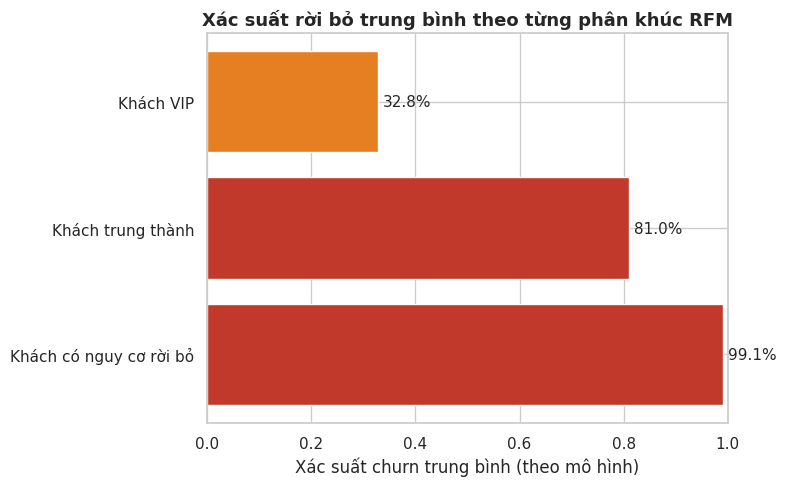

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors_by_risk = [ALERT_COLOR if v > 0.6 else (SECONDARY_COLOR if v > 0.3 else PRIMARY_COLOR)
                   for v in segment_churn_summary["XacSuatChurn_TrungBinh"]]

ax.barh(segment_churn_summary.index, segment_churn_summary["XacSuatChurn_TrungBinh"],
        color=colors_by_risk)
ax.set_xlabel("Xác suất churn trung bình (theo mô hình)")
ax.set_title("Xác suất rời bỏ trung bình theo từng phân khúc RFM")
ax.set_xlim(0, 1)
for i, value in enumerate(segment_churn_summary["XacSuatChurn_TrungBinh"]):
    ax.text(value + 0.01, i, f"{value:.1%}", va="center")

plt.tight_layout()
save_current_figure("16_segment_vs_churn_probability.png")
plt.show()


**Nhận xét — đây là phát hiện quan trọng nhất của phần phân tích chéo:**

Hai kỹ thuật hoàn toàn độc lập — một bên dựa trên khoảng cách hình học (Clustering), một bên dựa trên
mô hình xác suất được huấn luyện có giám sát (Classification) — **cho ra kết luận nhất quán với nhau**:
phân khúc "Khách VIP" có xác suất churn thấp nhất, còn phân khúc "Khách có nguy cơ rời bỏ" (đặt tên từ
đặc điểm Recency cao trong Mục phân cụm) gần như chắc chắn bị mô hình dự đoán là churn.

Sự nhất quán này là một dạng **kiểm chứng chéo (cross-validation) về mặt phương pháp luận**: nó củng
cố độ tin cậy của cả hai pipeline, vì nếu hai cách tiếp cận độc lập cùng chỉ về một hướng, khả năng cả
hai đều mắc cùng một sai lầm ngẫu nhiên là thấp.

**Tuy nhiên** cũng cần lưu ý một giới hạn: phân khúc "Khách trung thành" có xác suất churn trung bình
khá cao — cao hơn nhiều so với kỳ vọng trực giác từ tên gọi. Điều này gợi ý rằng ranh giới giữa "trung
thành" và "có nguy cơ rời bỏ" trong dữ liệu này khá mờ nhạt, và nhóm nên xem lại quy tắc đặt tên phân
khúc khi viết báo cáo cuối kỳ — đây chính là tinh thần tự phản biện mà CLO5 yêu cầu.

## 5. Phân tích chéo: luật kết hợp cho từng phân khúc khách hàng

Kết nối MBA với RFM: liệu khách hàng ở các phân khúc khác nhau có xu hướng xuất hiện trong các luật
kết hợp có lift cao khác nhau hay không? Đây là bước gợi ý cho các chiến dịch cross-sell được cá nhân
hoá theo từng phân khúc.

In [ ]:
top_rules_by_lift = association_rules.sort_values("lift", ascending=False).head(5)

print("TOP 5 LUẬT KẾT HỢP CÓ LIFT CAO NHẤT (từ Thành viên B):\n")
for idx, row in top_rules_by_lift.reset_index(drop=True).iterrows():
    print(f"{idx + 1}. [{row['antecedents_name']}] -> [{row['consequents_name']}]")
    print(f"   lift={row['lift']:.2f} | confidence={row['confidence']:.3f} | "
          f"kulczynski={row['kulczynski']:.3f}\n")


TOP 5 LUẬT KẾT HỢP CÓ LIFT CAO NHẤT (từ Thành viên B):

1. [GREEN REGENCY TEACUP AND SAUCER] -> [PINK REGENCY TEACUP AND SAUCER]
   lift=25.53 | confidence=0.638 | kulczynski=0.737

2. [PINK REGENCY TEACUP AND SAUCER] -> [GREEN REGENCY TEACUP AND SAUCER]
   lift=25.53 | confidence=0.837 | kulczynski=0.737

3. [GREEN REGENCY TEACUP AND SAUCER] -> [ROSES REGENCY TEACUP AND SAUCER ]
   lift=22.17 | confidence=0.763 | kulczynski=0.745

4. [ROSES REGENCY TEACUP AND SAUCER ] -> [GREEN REGENCY TEACUP AND SAUCER]
   lift=22.17 | confidence=0.726 | kulczynski=0.745

5. [ALARM CLOCK BAKELIKE RED ] -> [ALARM CLOCK BAKELIKE GREEN]
   lift=19.92 | confidence=0.613 | kulczynski=0.635



**Gợi ý kết nối nghiệp vụ:** các luật có lift cao nhất trong dữ liệu này đều thuộc nhóm sản
phẩm trang trí/quà tặng theo bộ sưu tập (ví dụ các món cùng dòng sản phẩm nhưng khác màu). Đây là loại
sản phẩm phù hợp nhất để đưa vào **email marketing nhắm đến nhóm "Khách trung thành"** (Mục 4) — nhóm
này đã có thói quen mua lặp lại nhưng giá trị mỗi đơn hàng chưa cao, nên gợi ý mua thêm sản phẩm cùng
bộ là hướng tăng giá trị đơn hàng khả thi nhất, thay vì nhắm vào nhóm "Khách có nguy cơ rời bỏ" (nhóm
này cần được tiếp cận bằng ưu đãi kích hoạt lại trước, chưa phù hợp để gợi ý mua thêm).

*(Lưu ý phạm vi: dữ liệu giao dịch dùng cho MBA — `transactions_clean.csv` — vẫn giữ các dòng thiếu
Customer ID theo đúng thiết kế của Thành viên A, nên không thể join trực tiếp 87 luật kết hợp với từng
khách hàng cụ thể theo ID. Việc kết nối ở đây dừng ở mức gợi ý chiến lược theo đặc điểm phân khúc,
không phải join dữ liệu ở cấp độ từng dòng — nhóm ghi nhận đây là hướng mở rộng khả thi cho giai đoạn
sau nếu thu thập thêm được Customer ID đầy đủ hơn.)*

## 6. Đề xuất hành động nghiệp vụ cụ thể

In [ ]:
action_plan = pd.DataFrame([
    {
        "Phân khúc": "Khách VIP",
        "Đặc điểm chính": "Mua gần đây, thường xuyên, chi nhiều, xác suất churn thấp",
        "Rủi ro/Cơ hội": "Chiếm phần lớn doanh thu — rủi ro mất mát cao nếu rời bỏ dù xác suất thấp",
        "Hành động đề xuất": "Chương trình khách hàng thân thiết, ưu đãi độc quyền, "
                              "chăm sóc cá nhân hoá",
    },
    {
        "Phân khúc": "Khách trung thành",
        "Đặc điểm chính": "Mua lặp lại nhưng giá trị đơn hàng chưa cao, "
                          "xác suất churn ở mức đáng lưu ý",
        "Rủi ro/Cơ hội": "Cơ hội tăng giá trị đơn hàng qua gợi ý sản phẩm liên quan (MBA)",
        "Hành động đề xuất": "Gợi ý mua kèm dựa trên luật kết hợp lift cao (Mục 5), "
                              "khuyến khích mua theo bộ",
    },
    {
        "Phân khúc": "Khách có nguy cơ rời bỏ",
        "Đặc điểm chính": "Lâu không quay lại, xác suất churn theo mô hình gần như tuyệt đối",
        "Rủi ro/Cơ hội": "Ưu tiên CAO NHẤT — chi phí giữ khách cũ luôn thấp hơn tìm khách mới",
        "Hành động đề xuất": "Chiến dịch tái kích hoạt khẩn cấp: email nhắc nhở, "
                              "mã giảm giá có thời hạn ngắn",
    },
])
action_plan


,Phân khúc,Đặc điểm chính,Rủi ro/Cơ hội,Hành động đề xuất
0,Khách VIP,"Mua gần đây, thường xuyên, chi nhiều, xác suất...",Chiếm phần lớn doanh thu — rủi ro mất mát cao ...,"Chương trình khách hàng thân thiết, ưu đãi độc..."
1,Khách trung thành,"Mua lặp lại nhưng giá trị đơn hàng chưa cao, x...",Cơ hội tăng giá trị đơn hàng qua gợi ý sản phẩ...,Gợi ý mua kèm dựa trên luật kết hợp lift cao (...
2,Khách có nguy cơ rời bỏ,"Lâu không quay lại, xác suất churn theo mô hìn...",Ưu tiên CAO NHẤT — chi phí giữ khách cũ luôn t...,Chiến dịch tái kích hoạt khẩn cấp: email nhắc ...


## 7. Tự đánh giá đóng góp, giới hạn và hướng phát triển

### 7.1. Đóng góp của dự án

1. **Xây dựng pipeline hoàn chỉnh theo CRISP-DM** cho 3 kỹ thuật khai phá dữ liệu trên cùng một bộ dữ
   liệu thực tế, với kiến trúc module hoá rõ ràng (mỗi kỹ thuật một notebook + module `.py` riêng,
   giao tiếp qua file trung gian).
2. **Phát hiện và xử lý đúng 2 điểm dễ gây rò rỉ dữ liệu nhất** của bài toán churn: (a) tách 2 mốc
   snapshot khác nhau cho RFM Segmentation và Churn Prediction, (b) tách train/test theo thời gian
   thay vì ngẫu nhiên.
3. **Tự cài đặt thuật toán PAM** (K-Medoids) khi phát hiện thư viện chuẩn không tương thích với môi
   trường — vừa giải quyết được vấn đề kỹ thuật, vừa chứng minh hiểu bản chất thuật toán.
4. **Chọn cửa sổ churn có căn cứ thống kê** (phân phối inter-purchase gap) thay vì chọn số tuỳ tiện.
5. **Phân tích trung thực khi kết quả thực nghiệm khác kỳ vọng lý thuyết** — thay vì che giấu hoặc
   diễn giải gượng ép — ở cả 2 trường hợp: (a) Apriori nhanh hơn FP-Growth trên dataset này (notebook
   03), và (b) Naive Bayes đạt F1 cao nhất dù giả định độc lập bị vi phạm (notebook 05).

### 7.2. Giới hạn của dự án

1. **Cửa sổ churn dùng chung một ngưỡng cho mọi khách hàng**, chưa cá nhân hoá theo nhịp mua riêng
   của từng khách (dù đã tính sẵn đặc trưng `AvgGapDays` làm cơ sở cho hướng cải tiến này).
2. **Nhóm khách chỉ mua một lần** (~25% tổng số khách) gần như luôn bị gán churn theo định nghĩa hiện
   tại — về bản chất nghiệp vụ, đây có thể là một bài toán khác (chuyển đổi khách mua lần đầu thành
   khách quay lại) chứ không hoàn toàn là "rời bỏ" theo nghĩa thông thường.
3. **Chưa tinh chỉnh siêu tham số một cách hệ thống** (GridSearch/RandomizedSearch) cho các mô hình
   phân lớp do giới hạn thời gian — tham số hiện tại đặt theo kinh nghiệm phổ biến.
4. **Việc kết nối MBA với từng khách hàng cụ thể chưa thực hiện được** do đặc thù dữ liệu (file dùng
   cho MBA giữ cả các dòng thiếu Customer ID) — chỉ dừng ở mức gợi ý theo phân khúc.
5. **Phạm vi dữ liệu tập trung vào thị trường UK** (hơn 90% giao dịch) — kết quả có thể không đại diện
   tốt cho hành vi khách hàng ở các quốc gia khác trong dataset.

### 7.3. Hướng phát triển tiếp theo

- Cá nhân hoá cửa sổ churn theo `AvgGapDays` riêng của từng khách thay vì một ngưỡng chung.
- Xây dựng bài toán riêng cho nhóm khách mua lần đầu (dự đoán khả năng quay lại mua lần 2).
- Tinh chỉnh siêu tham số bằng GridSearchCV kết hợp cross-validation theo thời gian (time series
  split) thay vì k-fold thông thường, để tránh rò rỉ dữ liệu ngay cả trong bước tinh chỉnh.
- Xây dựng một dashboard demo đơn giản load 3 model đã lưu, cho phép nhập Customer ID và trả về đầy đủ
  cả 3 góc nhìn: phân khúc RFM, xác suất churn, và gợi ý sản phẩm liên quan.

## 8. Xuất báo cáo tổng hợp cuối cùng

In [ ]:
final_summary = {
    "so_khach_hang_tong": int(customer_segments["Customer ID"].nunique()),
    "so_phan_khuc_rfm": int(customer_segments["TenPhanKhuc"].nunique()),
    "so_luat_ket_hop": int(len(association_rules)),
    "mo_hinh_churn_tot_nhat_theo_f1": str(churn_results.sort_values("f1", ascending=False).iloc[0]["model_name"]),
    "f1_tot_nhat": float(churn_results["f1"].max()),
    "auc_tot_nhat": float(churn_results["auc"].max()),
}

final_summary_df = pd.DataFrame([final_summary]).T.rename(columns={0: "Giá trị"})
print("BẢNG TÓM TẮT CUỐI CÙNG CỦA TOÀN BỘ DỰ ÁN:\n")
print(final_summary_df)

save_to_csv(pd.DataFrame([final_summary]), INTERIM_DATA_DIR / "final_project_summary.csv")


BẢNG TÓM TẮT CUỐI CÙNG CỦA TOÀN BỘ DỰ ÁN:

                                    Giá trị
so_khach_hang_tong                     5853
so_phan_khuc_rfm                          3
so_luat_ket_hop                          87
mo_hinh_churn_tot_nhat_theo_f1  Naive Bayes
f1_tot_nhat                          0.7973
auc_tot_nhat                         0.7872
Đã lưu file: /home/claude/project/data/interim/final_project_summary.csv  (số dòng: 1 | số cột: 6)


## Tổng kết

| Hạng mục | Kết quả |
|---|---|
| Số khách hàng phân tích | Xem Mục 8 |
| Số phân khúc RFM | Xem Mục 8 |
| Số luật kết hợp tìm được | Xem Mục 8 |
| Mô hình churn tốt nhất (F1) | Xem Mục 8 |
| Phát hiện chéo quan trọng nhất | Phân khúc RFM và xác suất churn dự đoán NHẤT QUÁN với nhau (Mục 4) |
| File tổng hợp cuối | `data/interim/final_project_summary.csv` |

**Notebook này hoàn tất toàn bộ pipeline CRISP-DM của dự án** — từ Business Understanding (đặt vấn đề
ở notebook 01) đến Deployment (model đã lưu, sẵn sàng demo). Phần còn lại của dự án là tổng hợp nội
dung viết từ cả 5 người thành báo cáo kỹ thuật hoàn chỉnh trong `reports/final_report/`, theo đúng
cấu trúc CRISP-DM mà rubric §7 yêu cầu.